# Variable Selection as Screening

Stepwise and best-subset procedures are common screening tools in regression software. This notebook implements the same ideas in Python and emphasizes their limitations.

By the end of this notebook, you should be able to:

- run forward/backward stepwise screening with transparent Python code;
- enumerate best subsets and compare adjusted $R^2$, AIC, BIC, Mallows $C_p$, and residual standard error;
- explain why selection methods induce Type I and Type II error risks;
- enforce hierarchy and validate the chosen model after screening.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()

Running outside JupyterLite; assuming packages are already installed.


In [2]:
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from checks import check_nonempty

sales = pd.read_csv(Path('data/territory_sales.csv'))
response = 'Sales'
predictors = ['Time', 'MarketPotential', 'Advertising', 'MarketShare', 'ChangeAccounts', 'Workload', 'Rating', 'CompetitorPressure']
sales[predictors + [response]].head()

,Time,MarketPotential,Advertising,MarketShare,ChangeAccounts,Workload,Rating,CompetitorPressure,Sales
0,18.69,59052.41,2376.75,11.468,-0.106,48.91,4.26,66.16,11257.91
1,20.19,58569.20,1969.18,9.959,-1.171,52.32,2.38,64.39,11994.85
2,18.48,60990.50,2187.94,10.175,0.527,52.24,2.51,55.96,13069.65
3,25.23,59934.74,2294.13,10.748,2.016,45.82,3.66,62.17,4757.93
4,28.04,63522.01,2987.64,12.532,-0.726,48.37,4.20,51.68,15276.56


## Stepwise Regression

Stepwise regression is an iterative screening procedure. Forward selection starts with no predictors and adds candidates. Backward elimination starts with the full model and removes weak candidates. Mixed stepwise can add and remove as the model changes.

The lecture warning matters: repeated tests inflate error rates. Treat stepwise results as an initial model-building suggestion, not as final evidence.

In [3]:
def fit_model(data, response, terms):
    formula = response + ' ~ ' + (' + '.join(terms) if terms else '1')
    return smf.ols(formula, data=data).fit()

def stepwise_pvalue(data, response, candidates, enter=0.05, remove=0.10):
    selected = []
    history = []
    remaining = list(candidates)
    while remaining:
        trial = []
        for term in remaining:
            model = fit_model(data, response, selected + [term])
            trial.append((model.pvalues.get(term, np.nan), term, model.aic))
        trial = sorted(trial)
        best_p, best_term, best_aic = trial[0]
        if best_p >= enter:
            break
        selected.append(best_term)
        remaining.remove(best_term)
        history.append({'action': 'add', 'term': best_term, 'p_value': best_p, 'aic': best_aic})
        changed = True
        while changed and selected:
            changed = False
            model = fit_model(data, response, selected)
            worst_term = model.pvalues.drop('Intercept').idxmax()
            worst_p = model.pvalues[worst_term]
            if worst_p > remove:
                selected.remove(worst_term)
                remaining.append(worst_term)
                history.append({'action': 'remove', 'term': worst_term, 'p_value': worst_p, 'aic': model.aic})
                changed = True
    return selected, pd.DataFrame(history)

selected, history = stepwise_pvalue(sales, response, predictors)
print(check_nonempty(selected, label='stepwise selection'))
print('Selected terms:', selected)
history

Correct: stepwise selection contains at least one item.
Selected terms: ['MarketShare']


,action,term,p_value,aic
0,add,MarketShare,6.059273e-10,670.55528


In [4]:
step_model = fit_model(sales, response, selected)
print(step_model.summary().tables[1])
print('Adjusted R-squared:', round(step_model.rsquared_adj, 4))
print('AIC:', round(step_model.aic, 2))

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept   -1.193e+04   3242.403     -3.678      0.001   -1.85e+04   -5336.166
MarketShare  2021.2400    237.411      8.514      0.000    1538.763    2503.716
Adjusted R-squared: 0.6713
AIC: 670.56


## Best Subset Regression

Best subset regression fits every candidate subset and then compares the best models of each size. Common criteria:

- $R^2$: increases when predictors are added, so it is not enough by itself.
- Adjusted $R^2$: penalizes extra predictors.
- $s = \sqrt{MSE}$: residual standard error, smaller is better.
- AIC/BIC: information criteria, smaller is better.
- Mallows $C_p$: one version is

$$C_p = \frac{SSE_p}{MSE_{full}} + 2(p+1) - n,$$

where $p$ is the number of predictors in the subset and $p+1$ counts the intercept.

In [5]:
def best_subsets(data, response, candidates):
    full = fit_model(data, response, candidates)
    mse_full = full.mse_resid
    rows = []
    for r in range(1, len(candidates) + 1):
        for combo in itertools.combinations(candidates, r):
            model = fit_model(data, response, list(combo))
            p = len(combo)
            cp = model.ssr / mse_full + 2 * (p + 1) - model.nobs
            rows.append({'predictors': combo, 'num_predictors': p, 'adj_r2': model.rsquared_adj,
                         'r2': model.rsquared, 's': np.sqrt(model.mse_resid), 'aic': model.aic,
                         'bic': model.bic, 'cp': cp})
    return pd.DataFrame(rows)

subsets = best_subsets(sales, response, predictors)
best_by_size = subsets.sort_values('adj_r2', ascending=False).groupby('num_predictors').head(1).sort_values('num_predictors')
best_by_size

,predictors,num_predictors,adj_r2,r2,s,aic,bic,cp
3,"(MarketShare,)",1,0.671309,0.680700,2610.645774,670.555280,673.722318,3.540605
22,"(Advertising, ChangeAccounts)",2,0.685368,0.703347,2554.200984,669.906785,674.657342,3.019772
36,"(Time, MarketPotential, Advertising)",3,0.698186,0.724056,2501.631802,669.301678,675.635754,2.714734
96,"(Time, MarketPotential, Advertising, Competito...",4,0.707897,0.741281,2461.056179,668.981335,676.898930,2.797497
168,"(Time, MarketPotential, Advertising, ChangeAcc...",5,0.711235,0.752487,2446.953919,669.387143,678.888257,3.550078
226,"(Time, MarketPotential, Advertising, ChangeAcc...",6,0.703844,0.754613,2478.074447,671.076614,682.161247,5.313459
247,"(Time, MarketPotential, Advertising, MarketSha...",7,0.696234,0.756987,2509.709745,672.726667,685.394818,7.049237
254,"(Time, MarketPotential, Advertising, MarketSha...",8,0.685557,0.757429,2553.436136,674.661077,688.912747,9.000000


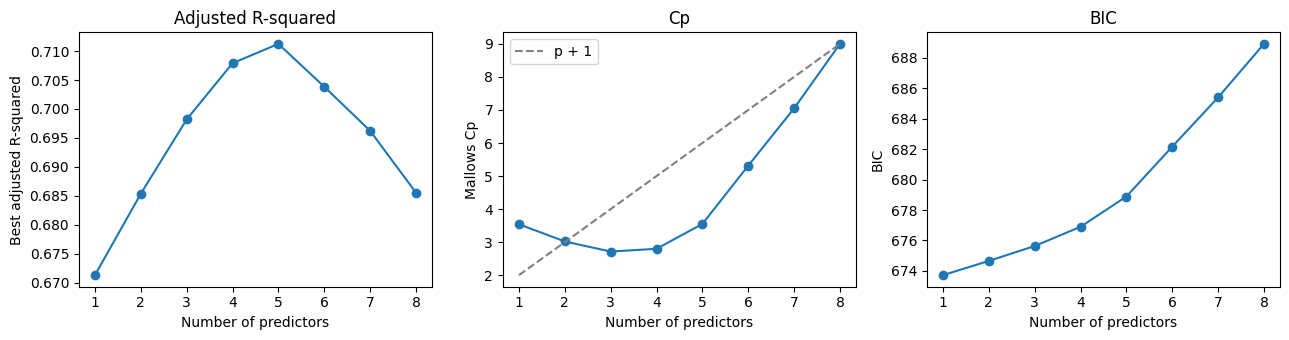

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(best_by_size['num_predictors'], best_by_size['adj_r2'], marker='o')
axes[0].set_xlabel('Number of predictors')
axes[0].set_ylabel('Best adjusted R-squared')
axes[0].set_title('Adjusted R-squared')
axes[1].plot(best_by_size['num_predictors'], best_by_size['cp'], marker='o')
axes[1].plot(best_by_size['num_predictors'], best_by_size['num_predictors'] + 1, linestyle='--', color='gray', label='p + 1')
axes[1].set_xlabel('Number of predictors')
axes[1].set_ylabel('Mallows Cp')
axes[1].set_title('Cp')
axes[1].legend()
axes[2].plot(best_by_size['num_predictors'], best_by_size['bic'], marker='o')
axes[2].set_xlabel('Number of predictors')
axes[2].set_ylabel('BIC')
axes[2].set_title('BIC')
plt.tight_layout()

Interpretation: look for a small model after which improvement is minor. If the selected model contains an interaction or polynomial term, preserve hierarchy by keeping the corresponding lower-order terms unless there is a strong course-approved reason not to.

In [7]:
bic_row = subsets.sort_values('bic').iloc[0]
bic_terms = list(bic_row['predictors'])
bic_model = fit_model(sales, response, bic_terms)
pd.DataFrame([
    {'model': 'stepwise', 'terms': tuple(selected), 'adj_r2': step_model.rsquared_adj, 'aic': step_model.aic, 'bic': step_model.bic},
    {'model': 'best_bic', 'terms': tuple(bic_terms), 'adj_r2': bic_model.rsquared_adj, 'aic': bic_model.aic, 'bic': bic_model.bic},
])

,model,terms,adj_r2,aic,bic
0,stepwise,"(MarketShare,)",0.671309,670.55528,673.722318
1,best_bic,"(MarketShare,)",0.671309,670.55528,673.722318


## Comparing Candidate Models with a Polynomial Term

Variable selection is not only about adding or removing different columns. Sometimes the candidate models use different forms of the same predictor. A common example is comparing a first-order model with a model that includes a quadratic term.

The next example compares two territory-sales models:

$$
\text{Model A: } Sales=\beta_0+\beta_1 Time+\beta_2 Rating+\epsilon,
$$

$$
\text{Model B: } Sales=\beta_0+\beta_1 Time+\beta_2 Rating+\beta_3 Rating^2+\epsilon.
$$

In Model B, the effect of `Rating` is not constant. Holding `Time` fixed, the fitted change in sales for a small one-unit change in rating is approximately

$$
\beta_2+2\beta_3 Rating.
$$

That is why a quadratic coefficient should be interpreted together with the corresponding linear term, not by itself.

In [8]:
candidate_a = smf.ols('Sales ~ Time + Rating', data=sales).fit()
candidate_b = smf.ols('Sales ~ Time + Rating + I(Rating ** 2)', data=sales).fit()

print('Model A coefficients')
print(candidate_a.params)
print('\nModel B coefficients')
print(candidate_b.params)
print('\nModel B coefficient tests')
print(candidate_b.summary().tables[1])


Model A coefficients
Intercept    5812.453380
Time           94.077900
Rating        777.504366
dtype: float64

Model B coefficients
Intercept         12510.540826
Time                 92.455474
Rating            -2568.794507
I(Rating ** 2)      408.295864
dtype: float64

Model B coefficient tests
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1.251e+04   9892.093      1.265      0.215   -7638.993    3.27e+04
Time              92.4555     24.350      3.797      0.001      42.857     142.054
Rating         -2568.7945   4787.748     -0.537      0.595   -1.23e+04    7183.530
I(Rating ** 2)   408.2959    571.970      0.714      0.480    -756.769    1573.361


The same fitted model object contains the overall F test and adjusted $R^2$. Use the overall F test to ask whether the model explains more variation than an intercept-only model. Use adjusted $R^2$ as one model-comparison summary that penalizes extra predictors.

In [9]:
comparison = pd.DataFrame({
    'model': ['A: linear rating', 'B: quadratic rating'],
    'overall_f': [candidate_a.fvalue, candidate_b.fvalue],
    'overall_f_pvalue': [candidate_a.f_pvalue, candidate_b.f_pvalue],
    'adj_r2': [candidate_a.rsquared_adj, candidate_b.rsquared_adj],
})
comparison


,model,overall_f,overall_f_pvalue,adj_r2
0,A: linear rating,24.926359,2.531736e-07,0.577564
1,B: quadratic rating,16.540467,1.142816e-06,0.571191


Prediction is also part of model comparison. At a chosen predictor setting, compare the fitted value, the confidence interval for the mean response, and the prediction interval for an individual future response. The prediction interval should be wider because it includes future observation noise.

In [10]:
new_territory = pd.DataFrame({'Time': [22], 'Rating': [4]})

pred_a = candidate_a.get_prediction(new_territory).summary_frame(alpha=0.05)
pred_b = candidate_b.get_prediction(new_territory).summary_frame(alpha=0.05)

def interval_widths(frame):
    row = frame.iloc[0]
    return pd.Series({
        'mean': row['mean'],
        'mean_ci_width': row['mean_ci_upper'] - row['mean_ci_lower'],
        'prediction_interval_width': row['obs_ci_upper'] - row['obs_ci_lower'],
    })

pd.DataFrame({
    'Model A': interval_widths(pred_a),
    'Model B': interval_widths(pred_b),
}).T


,mean,mean_ci_width,prediction_interval_width
Model A,10992.184638,4186.722431,12749.756424
Model B,10802.117047,4360.274099,12906.495456


## Caveats

Selection procedures perform many comparisons, can miss the true structure, can select models that violate hierarchy, and do not check assumptions. After screening, always run diagnostics, assess subject-matter plausibility, and validate prediction performance when possible.